<a href="https://colab.research.google.com/github/Impksoni/AlgoMath/blob/main/Cubic_Spline_Interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Cubic Spline Interpolation**

In [8]:
# Importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt

**Defining Function for core logic of cubic spline interpolation**

In [9]:
def cubic_spline(x, y):
    """
    Calculates the coefficients for cubic splines.

    Args:
        x (list or np.array): The x-coordinates of the data points.
        y (list or np.array): The y-coordinates of the data points.

    Returns:
        A tuple (a, b, c, d) of the spline coefficients.
    """
    n = len(x)
    # 'a' coefficients are just the y-values
    a = np.array(y, dtype=float)

    # 'h' is the spacing between the x-points
    h = np.array([x[i+1] - x[i] for i in range(n - 1)], dtype=float)

    # --- Step 1: Set up the tridiagonal system for the 'c' coefficients ---
    # This is based on the condition that the first and second derivatives
    # of the splines are continuous at the interior points.

    # Create the main diagonal of the matrix A
    A_main = np.array([2 * (h[i] + h[i+1]) for i in range(n - 2)], dtype=float)
    A = np.diag(A_main)

    # Create the upper and lower diagonals
    for i in range(n - 3):
        A[i, i+1] = h[i+1]
        A[i+1, i] = h[i+1]

    # Create the right-hand side vector 'B'
    B = np.array([
        3 * ((a[i+2] - a[i+1]) / h[i+1] - (a[i+1] - a[i]) / h[i])
        for i in range(n - 2)
    ], dtype=float)

    # --- Step 2: Solve the system Ac = B for 'c' ---
    # We assume natural splines, so c_0 = c_n = 0.
    # We solve for the interior c values (c_1 to c_{n-1}).
    c_interior = np.linalg.solve(A, B)

    # Form the full 'c' coefficient array
    c = np.zeros(n, dtype=float)
    c[1:-1] = c_interior

    # --- Step 3: Solve for the 'b' and 'd' coefficients ---
    b = np.zeros(n - 1, dtype=float)
    d = np.zeros(n - 1, dtype=float)

    for i in range(n - 1):
        b[i] = (a[i+1] - a[i]) / h[i] - h[i] * (c[i+1] + 2 * c[i]) / 3
        d[i] = (c[i+1] - c[i]) / (3 * h[i])

    # The coefficients are for the polynomials S_i(x) = a_i + b_i(x-x_i) + c_i(x-x_i)^2 + d_i(x-x_i)^3
    # We only need to return up to n-1 coefficients for b, c, and d.
    return a[:-1], b, c[:-1], d

**Defining Function to evaluate the spine**

In [10]:
# This function takes the calculated spline coefficients and evaluates the
# polynomial for a given set of x-values.

def evaluate_spline(x_data, x_eval, a, b, c, d):
    """
    Evaluates the cubic spline at given x-values.

    Args:
        x_data (np.array): The original x-coordinates of the data points.
        x_eval (np.array): The x-values at which to evaluate the spline.
        a, b, c, d (tuple): The spline coefficients.

    Returns:
        np.array: The interpolated y-values corresponding to x_eval.
    """
    y_eval = np.zeros_like(x_eval, dtype=float)

    for i, x_val in enumerate(x_eval):
        # Find which spline segment this x_val falls into
        # The searchsorted function is efficient for this.
        segment_idx = np.searchsorted(x_data, x_val) - 1

        # Handle cases where x_val is outside the original data range
        segment_idx = max(0, min(segment_idx, len(a) - 1))

        dx = x_val - x_data[segment_idx]

        # Evaluate the polynomial for this segment
        y_eval[i] = a[segment_idx] + b[segment_idx]*dx + c[segment_idx]*dx**2 + d[segment_idx]*dx**3

    return y_eval

**Providing some example data and executing it.**

In [11]:
# Here we define our sample data points and run the interpolation.

# Original data points
x_points = np.array([0, 1, 2, 3, 4, 5])
y_points = np.array([0, 2, 1, 4, 3, 0])

# Calculate the spline coefficients
a_coeffs, b_coeffs, c_coeffs, d_coeffs = cubic_spline(x_points, y_points)

# Generate a dense set of x-values for a smooth plot
x_smooth = np.linspace(x_points.min(), x_points.max(), 500)

# Evaluate the spline at the smooth x-values
y_smooth = evaluate_spline(x_points, x_smooth, a_coeffs, b_coeffs, c_coeffs, d_coeffs)

**Plotting the results in the graph**

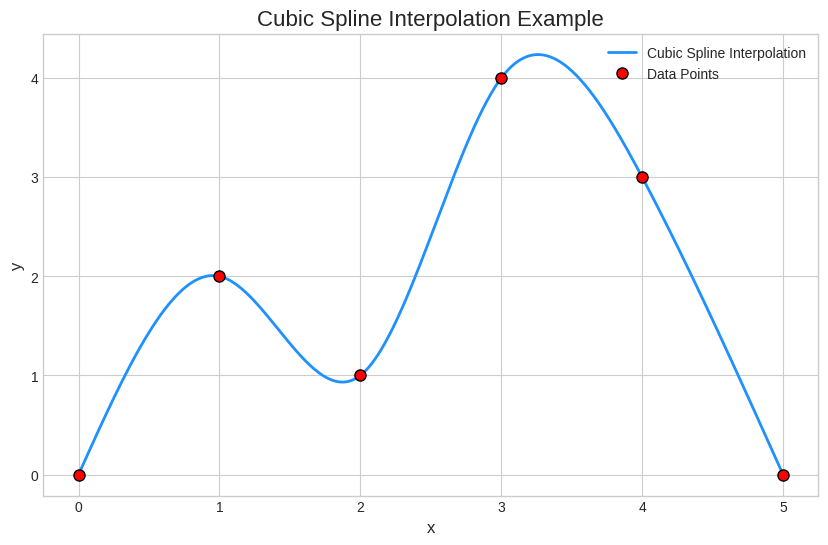

In [12]:
# Use matplotlib to visualize the original points and the smooth spline curve.

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the smooth spline curve
ax.plot(x_smooth, y_smooth, label='Cubic Spline Interpolation', color='dodgerblue', linewidth=2)

# Plot the original data points
ax.plot(x_points, y_points, 'o', label='Data Points', color='red', markersize=8, markeredgecolor='black')

# Adding titles and labels for clarity
ax.set_title('Cubic Spline Interpolation Example', fontsize=16)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True)

# Display the plot
plt.show()

In [13]:
# printing the coefficients of the polynomial equations
for i in range(len(a_coeffs)):
    print(f"Segment {i}: S(x) = {a_coeffs[i]:.2f} + {b_coeffs[i]:.2f}(x-{x_points[i]}) + {c_coeffs[i]:.2f}(x-{x_points[i]})^2 + {d_coeffs[i]:.2f}(x-{x_points[i]})^3")

Segment 0: S(x) = 0.00 + 3.16(x-0) + 0.00(x-0)^2 + -1.16(x-0)^3
Segment 1: S(x) = 2.00 + -0.32(x-1) + -3.47(x-1)^2 + 2.79(x-1)^3
Segment 2: S(x) = 1.00 + 1.11(x-2) + 4.89(x-2)^2 + -3.00(x-2)^3
Segment 3: S(x) = 4.00 + 1.89(x-3) + -4.11(x-3)^2 + 1.21(x-3)^3
Segment 4: S(x) = 3.00 + -2.68(x-4) + -0.47(x-4)^2 + 0.16(x-4)^3
